## Process similar claims and subsample for contradiction analysis

In [1]:
import pandas as pd

court_cases = pd.read_csv('../clean_data_with_details.csv')
print("Loaded court cases:", court_cases.shape)

similar_claims = pd.read_csv('../results/similarity_report.csv') # All claims similarities
print("Loaded similar claims:", similar_claims.shape)

Loaded court cases: (3303, 18)
Loaded similar claims: (54815685, 9)


<Axes: title={'center': 'Distribution of Similarity Scores between Case Claims'}, ylabel='Frequency'>

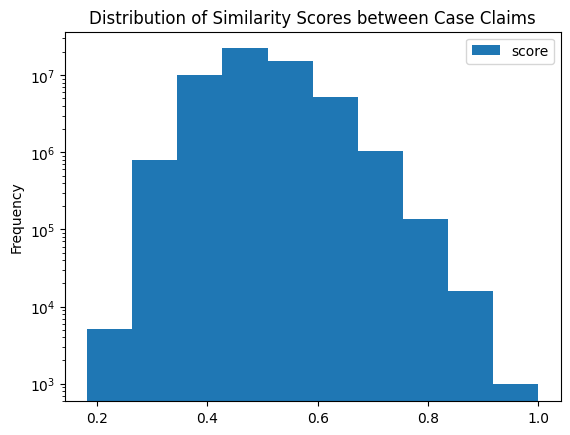

In [3]:
similar_claims.plot.hist(column='score', bins=10, logy=True, title='Distribution of Similarity Scores between Case Claims')

In [ ]:
# Get the similarity of ALL claim pairs [done]
# Uniformly select 10K claim pairs based on similarity
# Look at where contradicting claims appear in distribution
# Pray its not uniform

In [4]:
# Sample 10K claim pairs uniformly across similarity scores
subsample_data = pd.concat([
    # similar_claims[similar_claims['score'] <= 0.1].sample(n=1000, random_state=42), # zero in this bin
    # similar_claims[(similar_claims['score'] > 0.1) & (similar_claims['score'] <= 0.2)].sample(n=1000, random_state=42), # zero in this bin too
    similar_claims[(similar_claims['score'] > 0.2) & (similar_claims['score'] <= 0.3) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.3) & (similar_claims['score'] <= 0.4) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.4) & (similar_claims['score'] <= 0.5) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.5) & (similar_claims['score'] <= 0.6) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.6) & (similar_claims['score'] <= 0.7) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.7) & (similar_claims['score'] <= 0.8) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.8) & (similar_claims['score'] <= 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
])

In [5]:
subsample_data_with_facts = subsample_data.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket1', 'name1'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts1',
        'api_question': 'api_question1',
        'api_conclusion': 'api_conclusion1'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket2', 'name2'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts2',
        'api_question': 'api_question2',
        'api_conclusion': 'api_conclusion2'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts[['claim1', 'docket1', 'name1', 'facts1', 'api_question1', 'api_conclusion1', 'claim2', 'docket2', 'name2', 'facts2', 'api_question2', 'api_conclusion2', 'score']]

<Axes: title={'center': 'Distribution of Similarity Scores in Subsample'}, ylabel='Frequency'>

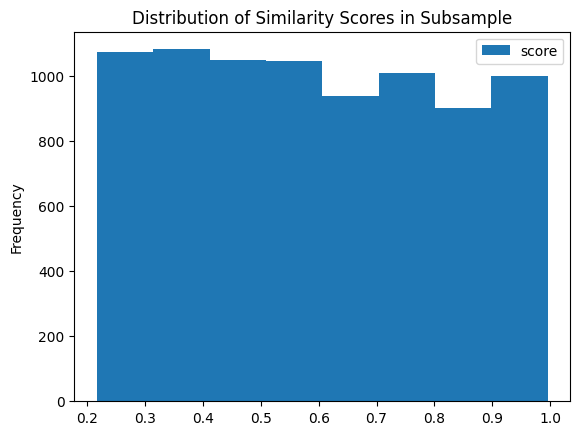

In [6]:
subsample_data_with_facts.plot.hist(column='score', bins=8, title='Distribution of Similarity Scores in Subsample')

In [7]:
# Contradiction Prompt
PROMPT_TEMPLATE = """You are a legal expert. Read two short claims from different cases and the two cases' associated facts, legal questions, and conclusions.
Decide whether the two claims are contradicting (negation or opposite entailment), or consistent (when they are unrelated or entail).
You must output an explanation for your decision in the "explanation" field. Then, also provide a decision in the "contradiction" field: "contradiction" if the claims are contradicting, and "consistent" if they are not.

## Output Format:
Return a JSON object in the following format:
```json
{{
    "explanation": "...",
    "contradiction": "<contradiction/consistent>",
    ...
}}
```

Claim 1: {claim1}
Claim 2: {claim2}

Claim 1 Case Evidence:
Facts: {facts1}
Legal Question: {api_question1}
Conclusion: {api_conclusion1}

Claim 2 Case Evidence:
Facts: {facts2}
Legal Question: {api_question2}
Conclusion: {api_conclusion2}
"""

subsample_data_with_facts['prompt'] = subsample_data_with_facts.apply(lambda row: PROMPT_TEMPLATE.format(
    **row
), axis=1)

In [8]:
subsample_data_with_facts.to_json('../subsampled_claims_for_contradiction_analysis.jsonl', orient='records', lines=True)

In [9]:
# Overlap Prompt
PROMPT_TEMPLATE = """You are a legal expert. Read two short claims from different cases and the two cases' associated facts, legal questions, and conclusions.
Decide whether the two claims are saying the same thing (being redundant) or are meaningfully different regarding their meaning.
You must output an explanation for your decision in the "explanation" field. Then, also provide a decision in the "overlap" field: "redundant" if the claims are redundant, and "different" if they are not.

## Output Format:
Return a JSON object in the following format:
```json
{{
    "explanation": "...",
    "overlap": "<redundant/different>",
    ...
}}
```

Claim 1: {claim1}
Claim 2: {claim2}

Claim 1 Case Evidence:
Facts: {facts1}
Legal Question: {api_question1}
Conclusion: {api_conclusion1}

Claim 2 Case Evidence:
Facts: {facts2}
Legal Question: {api_question2}
Conclusion: {api_conclusion2}
"""

subsample_data_with_facts['prompt'] = subsample_data_with_facts.apply(lambda row: PROMPT_TEMPLATE.format(
    **row
), axis=1)

In [10]:
subsample_data_with_facts.to_json('../subsampled_claims_for_overlap_analysis.jsonl', orient='records', lines=True)

In [12]:
with open('../subsampled_claims_for_contradiction_analysis.jsonl', 'r') as f1, open('../subsampled_claims_for_overlap_analysis.jsonl', 'r') as f2:
	content1 = f1.read()
	content2 = f2.read()
	assert content1 != content2, "The two files are identical!"
print("The two files are not identical.")

The two files are not identical.


## Prompt LLM

In [ ]:
# Generate LLM outputs for contradiction analysis
!python ../gemma3_vllm_flexible.py \
  --prompts ../subsampled_claims_for_contradiction_analysis.jsonl \
  --output ../subsampled_claims_for_contradiction_analysis_vllm.jsonl \
  --tp 4

In [ ]:
# Generate LLM outputs for overlap analysis
!python ../gemma3_vllm_flexible.py \
  --prompts ../subsampled_claims_for_overlap_analysis.jsonl \
  --output ../subsampled_claims_for_overlap_analysis_vllm.jsonl \
  --tp 4

## Analyze LLM responses

In [1]:
import pandas as pd
import json
import re
import os

def extract_json(text):
    try:
        match = re.search(r"```json\s*(\{.*?\})\s*```", text, re.DOTALL)
        if match:
            return json.loads(match.group(1))
        match = re.search(r"(\{.*\})", text, re.DOTALL)
        if match:
            return json.loads(match.group(1))
        return {}
    except:
        return {}

# Load Inputs (to get scores and metadata)
print("Loading input data...")
input_contra = pd.read_json('../subsampled_claims_for_contradiction_analysis.jsonl', lines=True)
input_overlap = pd.read_json('../subsampled_claims_for_overlap_analysis.jsonl', lines=True)

# Load Outputs
print("Loading LLM outputs...")
output_contra_path = '../subsampled_claims_for_contradiction_analysis_vllm.jsonl'
output_overlap_path = '../subsampled_claims_for_overlap_analysis_vllm.jsonl'

if os.path.exists(output_contra_path) and os.path.exists(output_overlap_path):
    output_contra = pd.read_json(output_contra_path, lines=True)
    output_overlap = pd.read_json(output_overlap_path, lines=True)

    # Process Contradiction
    print("Processing Contradiction Results...")
    if len(input_contra) == len(output_contra):
        output_contra['score'] = input_contra['score']
        output_contra['claim1'] = input_contra['claim1']
        output_contra['claim2'] = input_contra['claim2']
        
        output_contra['parsed'] = output_contra['answer'].apply(extract_json)
        output_contra['decision'] = output_contra['parsed'].apply(lambda x: x.get('contradiction', 'error'))
        output_contra['explanation'] = output_contra['parsed'].apply(lambda x: x.get('explanation', ''))
        
        output_contra.to_csv('../results/contradiction_subsample_results.csv', index=False)
        print("Saved contradiction results to ../results/contradiction_subsample_results.csv")
    else:
        print(f"Warning: Length mismatch for contradiction files. Input: {len(input_contra)}, Output: {len(output_contra)}")

    # Process Overlap
    print("Processing Overlap Results...")
    if len(input_overlap) == len(output_overlap):
        output_overlap['score'] = input_overlap['score']
        output_overlap['claim1'] = input_overlap['claim1']
        output_overlap['claim2'] = input_overlap['claim2']
        
        output_overlap['parsed'] = output_overlap['answer'].apply(extract_json)
        output_overlap['decision'] = output_overlap['parsed'].apply(lambda x: x.get('overlap', 'error'))
        output_overlap['explanation'] = output_overlap['parsed'].apply(lambda x: x.get('explanation', ''))
        
        output_overlap.to_csv('../results/overlap_subsample_results.csv', index=False)
        print("Saved overlap results to ../results/overlap_subsample_results.csv")
    else:
        print(f"Warning: Length mismatch for overlap files. Input: {len(input_overlap)}, Output: {len(output_overlap)}")
else:
    print("Output files not found. Please run the generation cells first.")

Loading input data...
Loading LLM outputs...
Processing Contradiction Results...
Saved contradiction results to ../results/contradiction_subsample_results.csv
Processing Overlap Results...
Saved overlap results to ../results/overlap_subsample_results.csv


Total Samples: 8094
Contradictions: 82 (1.01%)
Contradiction Similarity Score Ranges:
  50% of samples fall between 0.8203 and 0.9180
  68% of samples fall between 0.8086 and 0.9220
  75% of samples fall between 0.8052 and 0.9258
  95% of samples fall between 0.7032 and 0.9491

Overlaps: 555 (6.86%)
Overlap Similarity Score Ranges:
  50% of samples fall between 0.9023 and 0.9336
  68% of samples fall between 0.8658 and 0.9428
  75% of samples fall between 0.8516 and 0.9453
  95% of samples fall between 0.8047 and 0.9688
------------------------------


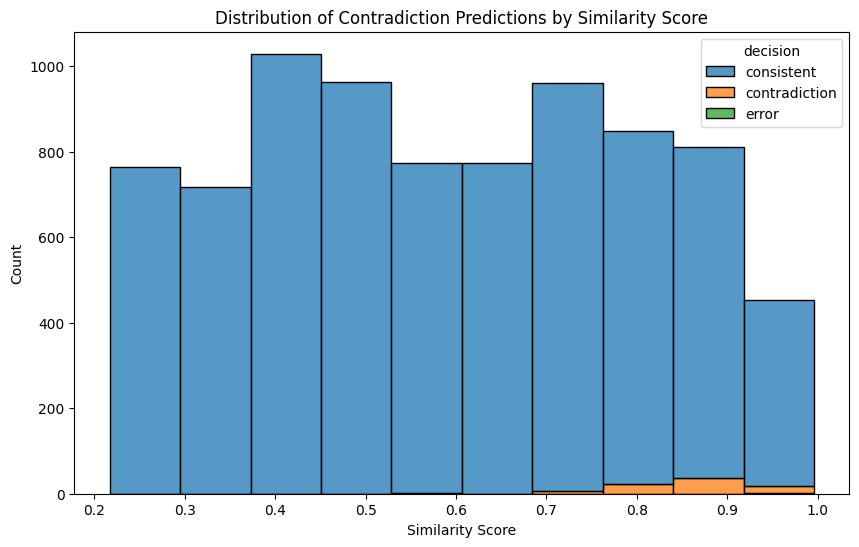

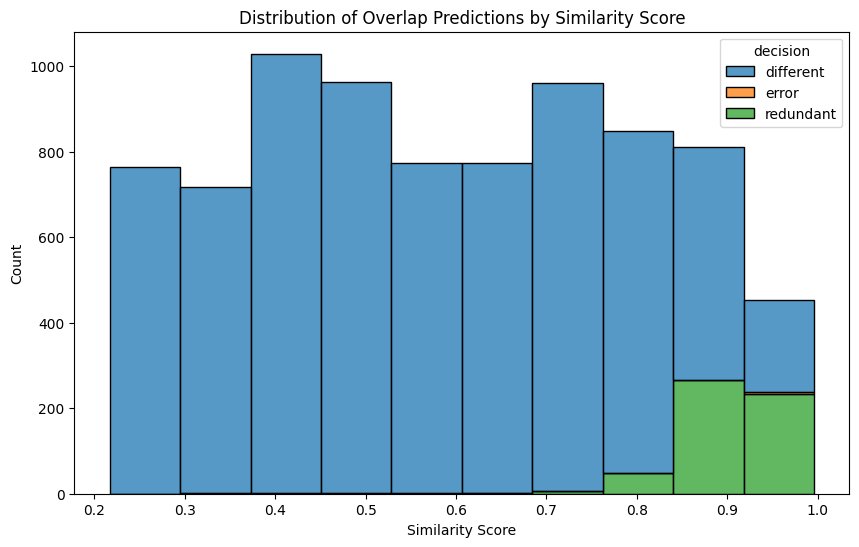

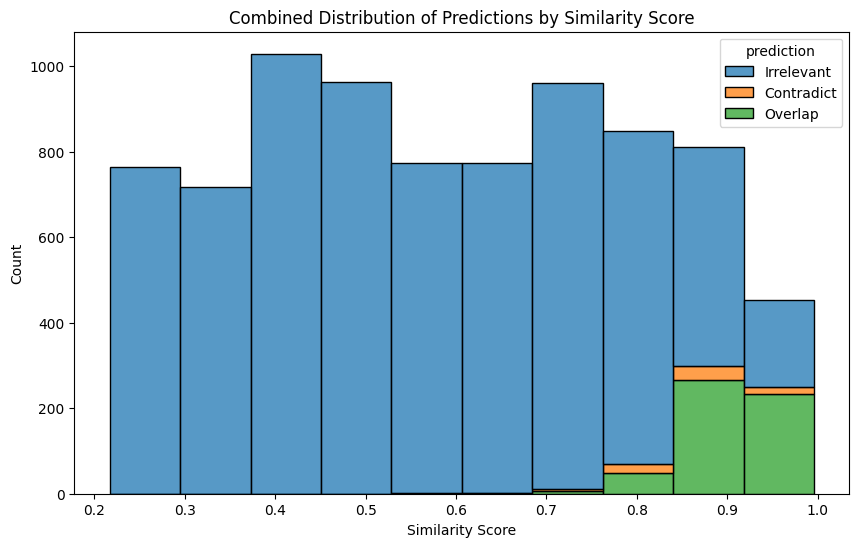

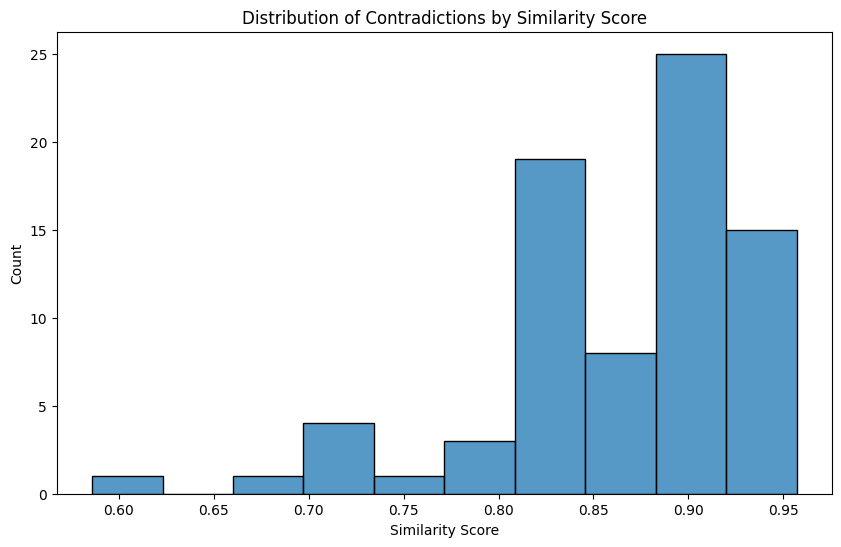

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# Reload data from CSVs to ensure we are working with saved data
if os.path.exists('../results/contradiction_subsample_results.csv') and os.path.exists('../results/overlap_subsample_results.csv'):
    df_contra = pd.read_csv('../results/contradiction_subsample_results.csv')
    df_overlap = pd.read_csv('../results/overlap_subsample_results.csv')

    # Normalize decision strings
    df_contra['decision'] = df_contra['decision'].str.lower()
    df_overlap['decision'] = df_overlap['decision'].str.lower()

    # --- Statistical Analysis ---
    total_samples = len(df_contra)
    
    # Contradictions
    contradictions = df_contra[df_contra['decision'] == 'contradiction']
    contra_count = len(contradictions)
    contra_pct = (contra_count / total_samples) * 100
    
    print(f"Total Samples: {total_samples}")
    print(f"Contradictions: {contra_count} ({contra_pct:.2f}%)")
    
    if contra_count > 0:
        scores = contradictions['score']
        print("Contradiction Similarity Score Ranges:")
        for p in [50, 68, 75, 95]:
            lower = (100 - p) / 2
            upper = 100 - lower
            l_val = np.percentile(scores, lower)
            u_val = np.percentile(scores, upper)
            print(f"  {p}% of samples fall between {l_val:.4f} and {u_val:.4f}")

    # Overlaps
    overlaps = df_overlap[df_overlap['decision'] == 'redundant']
    overlap_count = len(overlaps)
    overlap_pct = (overlap_count / total_samples) * 100
    
    print(f"\nOverlaps: {overlap_count} ({overlap_pct:.2f}%)")
    
    if overlap_count > 0:
        scores = overlaps['score']
        print("Overlap Similarity Score Ranges:")
        for p in [50, 68, 75, 95]:
            lower = (100 - p) / 2
            upper = 100 - lower
            l_val = np.percentile(scores, lower)
            u_val = np.percentile(scores, upper)
            print(f"  {p}% of samples fall between {l_val:.4f} and {u_val:.4f}")
    print("-" * 30)
    # ----------------------------

    # Plot 1: Contradiction Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_contra, x='score', hue='decision', multiple='stack', bins=10)
    plt.title('Distribution of Contradiction Predictions by Similarity Score')
    plt.xlabel('Similarity Score')
    plt.ylabel('Count')
    plt.show()

    # Plot 2: Overlap Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_overlap, x='score', hue='decision', multiple='stack', bins=10)
    plt.title('Distribution of Overlap Predictions by Similarity Score')
    plt.xlabel('Similarity Score')
    plt.ylabel('Count')
    plt.show()

    # Combined Analysis
    # Since inputs were identical, we can merge on index or claim pairs
    # Let's assume index alignment as verified before
    combined_df = df_contra[['score', 'claim1', 'claim2']].copy()
    combined_df['contradiction_decision'] = df_contra['decision']
    combined_df['overlap_decision'] = df_overlap['decision']

    def categorize(row):
        if row['overlap_decision'] == 'redundant':
            return 'Overlap'
        elif row['contradiction_decision'] == 'contradiction':
            return 'Contradict'
        else:
            return 'Irrelevant' # or Consistent/Different

    combined_df['prediction'] = combined_df.apply(categorize, axis=1)

    # Plot 3: Combined Distribution (Similar to user's first image)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_df, x='score', hue='prediction', multiple='stack', bins=10)
    plt.title('Combined Distribution of Predictions by Similarity Score')
    plt.xlabel('Similarity Score')
    plt.ylabel('Count')
    plt.show()

    # Plot 4: Contradict only (Similar to user's second image)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_df[combined_df['prediction'] == 'Contradict'], x='score', bins=10)
    plt.title('Distribution of Contradictions by Similarity Score')
    plt.xlabel('Similarity Score')
    plt.ylabel('Count')
    plt.show()
else:
    print("Results CSVs not found. Please run the extraction cell first.")